In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os

print(os.listdir('/content/drive/MyDrive'))


['JAVA programms.zip', 'colab ml', 'Colab Notebooks', '2520030452_Apaar ID.pdf', 'ML - project']


In [7]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if 'Mall' in file:
            print(os.path.join(root, file))

/content/drive/MyDrive/ML - project/Mall_Customers  Dataset.csv


In [8]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/ML - project/Mall_Customers  Dataset.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [9]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (200, 5)

Columns:
['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [10]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (200, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [11]:
df.head(10)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [12]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [13]:
print("Number of duplicate records:", df.duplicated().sum())

Number of duplicate records: 0


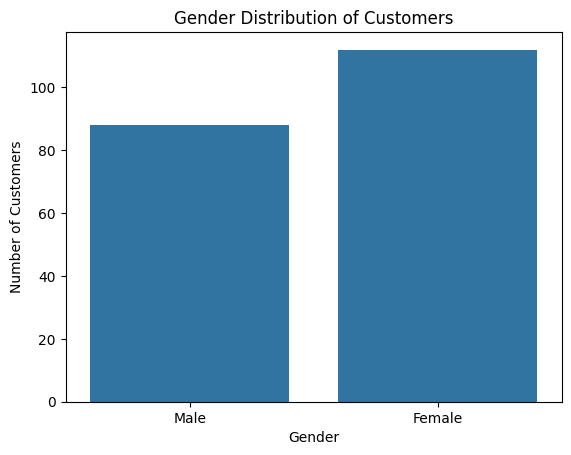

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Gender', data=df)

plt.title('Gender Distribution of Customers')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.show()

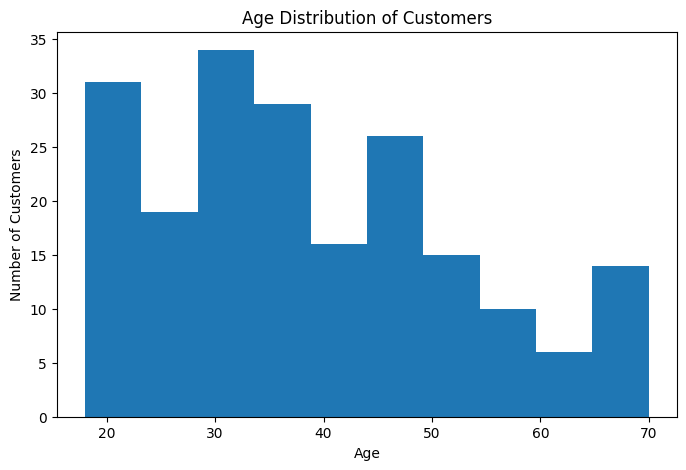

In [16]:
plt.figure(figsize=(8,5))

plt.hist(df['Age'], bins=10)

plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

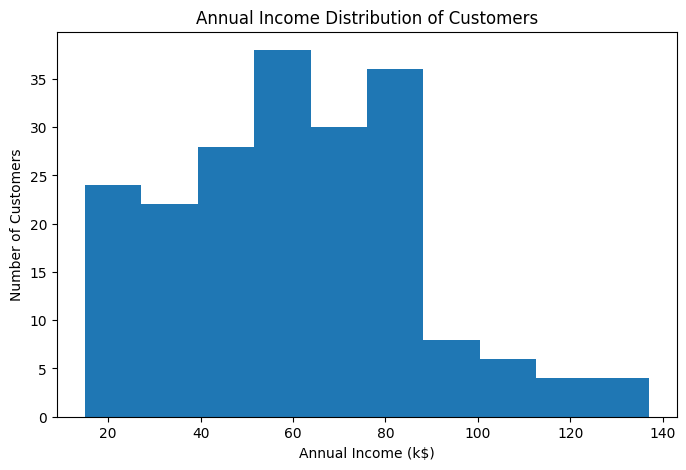

In [17]:
plt.figure(figsize=(8,5))

plt.hist(df['Annual Income (k$)'], bins=10)

plt.title('Annual Income Distribution of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Number of Customers')

plt.show()

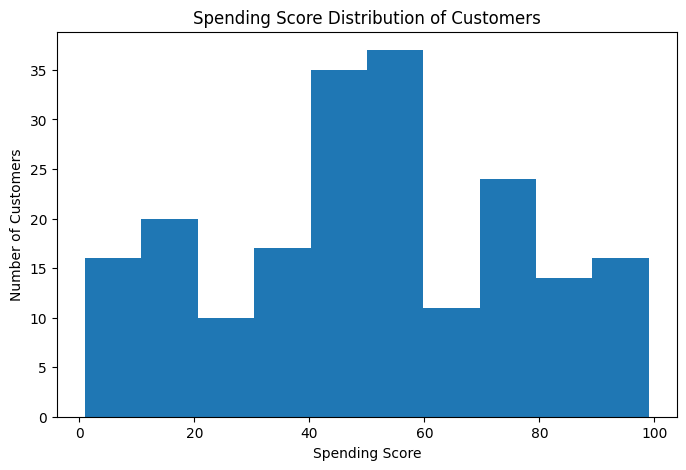

In [18]:
plt.figure(figsize=(8,5))

plt.hist(df['Spending Score (1-100)'], bins=10)

plt.title('Spending Score Distribution of Customers')
plt.xlabel('Spending Score')
plt.ylabel('Number of Customers')

plt.show()

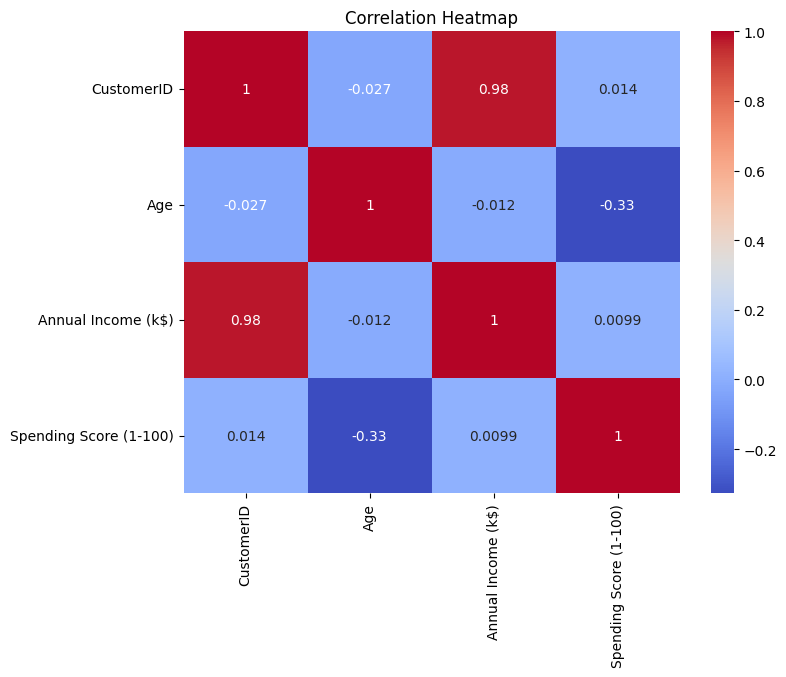

In [19]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include='number')

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

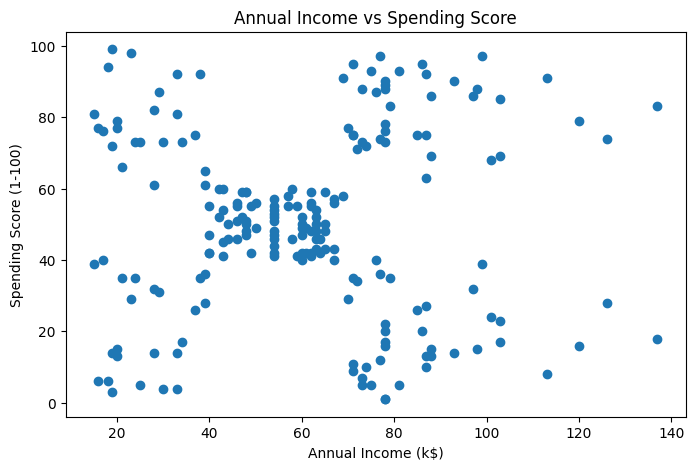

In [20]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)']
)

plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.show()

In [21]:
print("EDA Findings")
print("--------------------")

print("1. Total number of customers:", len(df))

print("2. Female customers:", (df['Gender'] == 'Female').sum())
print("3. Male customers:", (df['Gender'] == 'Male').sum())

print("4. Average Age:", round(df['Age'].mean(), 2))

print("5. Average Annual Income (k$):",
      round(df['Annual Income (k$)'].mean(), 2))

print("6. Average Spending Score:",
      round(df['Spending Score (1-100)'].mean(), 2))

print("7. Minimum Annual Income:",
      df['Annual Income (k$)'].min())

print("8. Maximum Annual Income:",
      df['Annual Income (k$)'].max())

print("9. Minimum Spending Score:",
      df['Spending Score (1-100)'].min())

print("10. Maximum Spending Score:",
      df['Spending Score (1-100)'].max())

EDA Findings
--------------------
1. Total number of customers: 200
2. Female customers: 112
3. Male customers: 88
4. Average Age: 38.85
5. Average Annual Income (k$): 60.56
6. Average Spending Score: 50.2
7. Minimum Annual Income: 15
8. Maximum Annual Income: 137
9. Minimum Spending Score: 1
10. Maximum Spending Score: 99


In [23]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [24]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


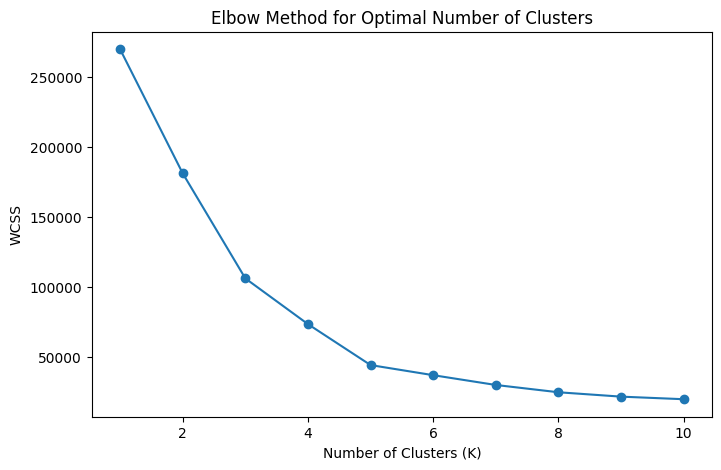

In [25]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')

plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')

plt.show()

In [26]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

kmeans.fit(X)

df['Cluster'] = kmeans.labels_

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


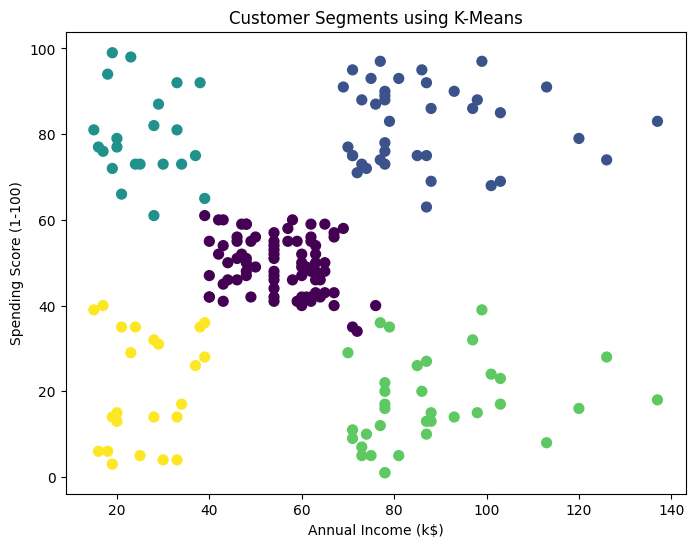

In [27]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=df['Cluster'],
    s=50
)

plt.title('Customer Segments using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.show()

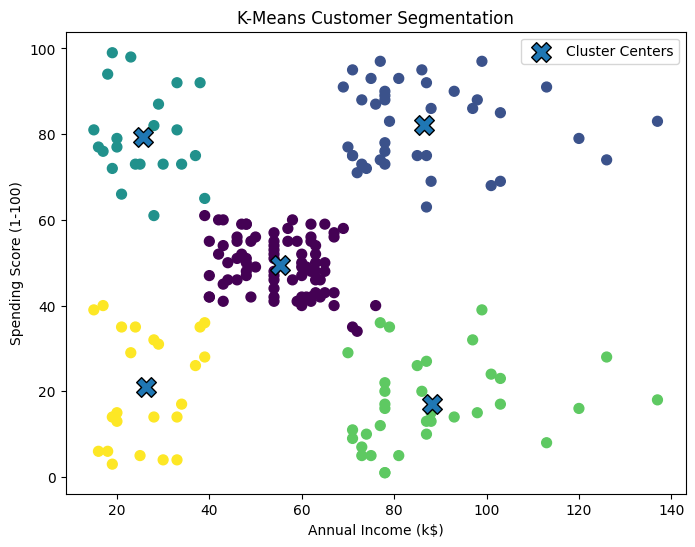

In [28]:
centers = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=df['Cluster'],
    s=50
)

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    s=200,
    marker='X',
    edgecolor='black',
    label='Cluster Centers'
)

plt.title('K-Means Customer Segmentation')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()

plt.show()

In [29]:
cluster_counts = df['Cluster'].value_counts().sort_index()

print("Number of customers in each cluster:")
print(cluster_counts)

Number of customers in each cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [30]:
cluster_summary = df.groupby('Cluster')[
    ['Annual Income (k$)', 'Spending Score (1-100)']
].mean()

print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043


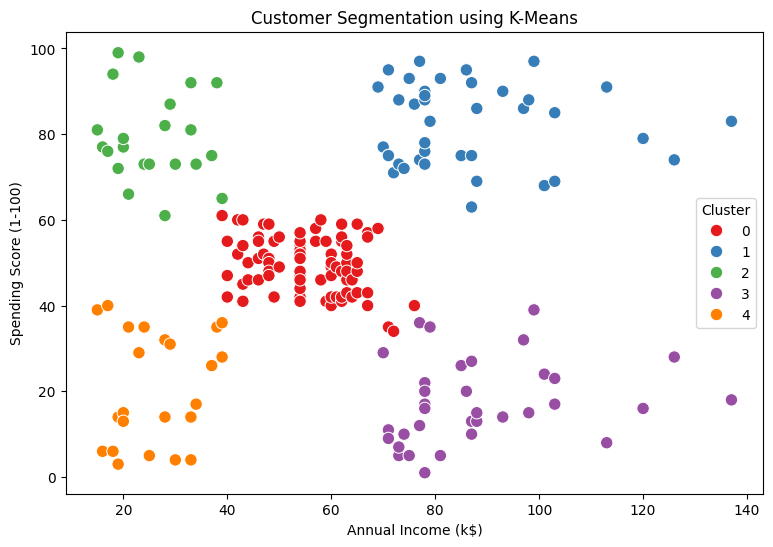

In [31]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set1',
    s=80
)

plt.title('Customer Segmentation using K-Means')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')

plt.show()

In [33]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

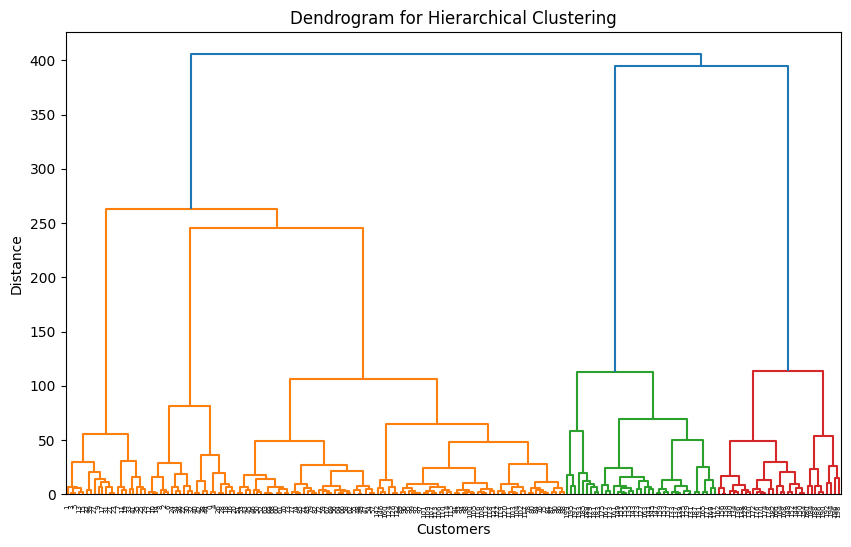

In [34]:
plt.figure(figsize=(10, 6))

linked = linkage(X, method='ward')

dendrogram(linked)

plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Customers')
plt.ylabel('Distance')

plt.show()

In [35]:
hierarchical = AgglomerativeClustering(
    n_clusters=5,
    linkage='ward'
)

df['Hierarchical_Cluster'] = hierarchical.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Hierarchical_Cluster
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,2,3
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,2,3
4,5,Female,31,17,40,4,4


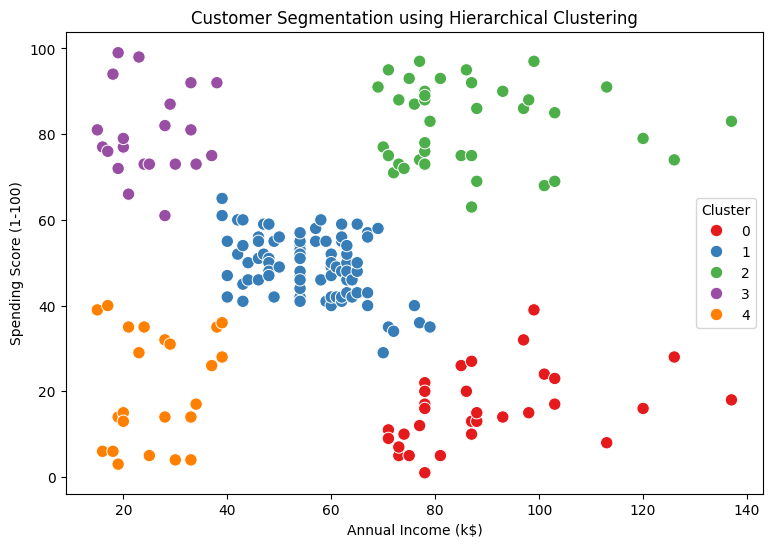

In [36]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Hierarchical_Cluster',
    palette='Set1',
    s=80
)

plt.title('Customer Segmentation using Hierarchical Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(title='Cluster')

plt.show()

In [37]:
comparison = pd.DataFrame({
    'K-Means': df['Cluster'].value_counts().sort_index(),
    'Hierarchical': df['Hierarchical_Cluster'].value_counts().sort_index()
})

print("Cluster Size Comparison:")
print(comparison)

Cluster Size Comparison:
   K-Means  Hierarchical
0       81            32
1       39            85
2       22            39
3       35            21
4       23            23


In [38]:
kmeans_summary = df.groupby('Cluster')[
    ['Annual Income (k$)', 'Spending Score (1-100)']
].mean()

hierarchical_summary = df.groupby('Hierarchical_Cluster')[
    ['Annual Income (k$)', 'Spending Score (1-100)']
].mean()

print("K-Means Cluster Summary:")
print(kmeans_summary)

print("\nHierarchical Cluster Summary:")
print(hierarchical_summary)

K-Means Cluster Summary:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043

Hierarchical Cluster Summary:
                      Annual Income (k$)  Spending Score (1-100)
Hierarchical_Cluster                                            
0                              89.406250               15.593750
1                              55.811765               49.129412
2                              86.538462               82.128205
3                              25.095238               80.047619
4                              26.304348               20.913043


In [39]:
print("PROJECT CONCLUSION")
print("------------------")

print("1. Customer data was successfully analyzed using Exploratory Data Analysis (EDA).")

print("2. K-Means clustering was applied to segment customers based on Annual Income and Spending Score.")

print("3. Hierarchical Clustering was also applied to identify customer groups.")

print("4. Both methods produced meaningful customer segments.")

print("5. The clustering results can help identify different customer groups for targeted marketing and personalized offers.")

PROJECT CONCLUSION
------------------
1. Customer data was successfully analyzed using Exploratory Data Analysis (EDA).
2. K-Means clustering was applied to segment customers based on Annual Income and Spending Score.
3. Hierarchical Clustering was also applied to identify customer groups.
4. Both methods produced meaningful customer segments.
5. The clustering results can help identify different customer groups for targeted marketing and personalized offers.
